Silakan klik tombol 'Capture Photo' yang muncul...


<IPython.core.display.Javascript object>

Sedang memproses deteksi...
Hasil Deteksi dengan Label:


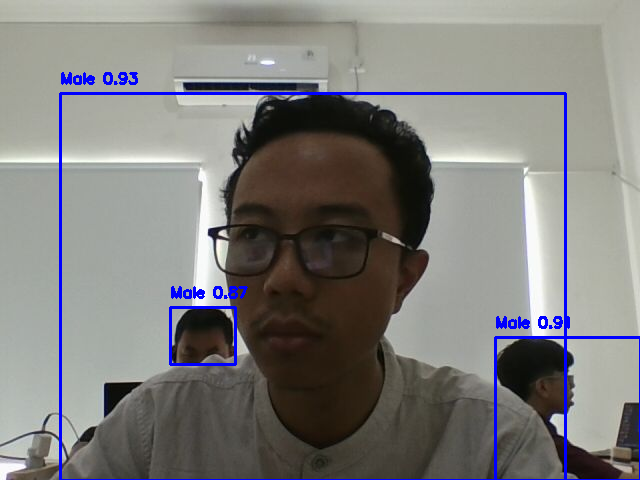

In [2]:
!pip install -q -U inference-sdk opencv-python

import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import output
from IPython.display import display, Javascript
from inference_sdk import InferenceHTTPClient
import base64

# Initialize client
client = InferenceHTTPClient.init(
    api_url="https://serverless.roboflow.com",
    api_key="06dt0tm73UqIouz3rKfJ"
)

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Photo';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = output.eval_js('takePhoto({})'.format(quality))
  binary = base64.b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

try:
  # 1. Ambil Foto
  print("Silakan klik tombol 'Capture Photo' yang muncul...")
  filename = take_photo()

  # 2. Jalankan Workflow Roboflow
  print("Sedang memproses deteksi...")
  result = client.run_workflow(
      workspace_name="teguh-rijanandi",
      workflow_id="find-females-and-males",
      images={"image": filename}
  )

  # 3. Manual Annotation (Drawing labels and boxes)
  img = cv2.imread(filename)
  if isinstance(result, list) and len(result) > 0:
      predictions = result[0].get('predictions', {}).get('predictions', [])

      for pred in predictions:
          # Ambil data dari JSON
          x_center, y_center = pred['x'], pred['y']
          w, h = pred['width'], pred['height']
          label = pred['class']
          conf = pred['confidence']

          # Hitung koordinat kotak
          x1, y1 = int(x_center - w/2), int(y_center - h/2)
          x2, y2 = int(x_center + w/2), int(y_center + h/2)

          # Warna: Biru untuk Male, Merah untuk Female
          color = (255, 0, 0) if label.lower() == 'male' else (0, 0, 255)

          # Gambar kotak dan teks
          cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
          text = f"{label} {conf:.2f}"
          cv2.putText(img, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

      print("Hasil Deteksi dengan Label:")
      cv2_imshow(img)
  else:
      print("Tidak ada objek terdeteksi.")
      cv2_imshow(img)

except Exception as err:
  print(f"Terjadi kesalahan: {err}")

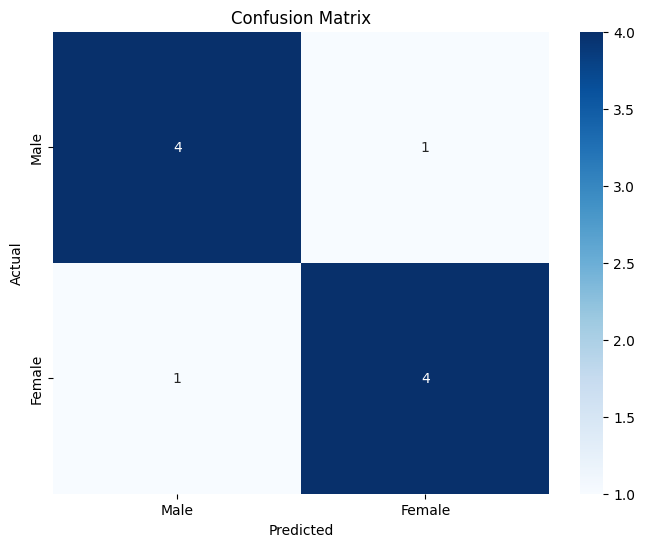


--- Classification Report ---
              precision    recall  f1-score   support

        Male       0.80      0.80      0.80         5
      Female       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

F1-Score: 0.8000


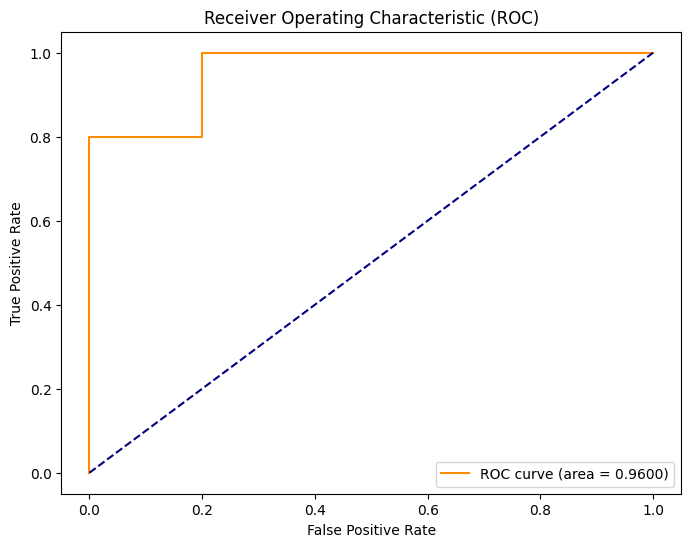

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve, classification_report

def evaluate_model(y_true, y_pred, y_probs):
    """
    Fungsi untuk menampilkan metrik evaluasi.
    y_true: Label asli (0 untuk Male, 1 untuk Female)
    y_pred: Label prediksi dari model
    y_probs: Probabilitas/Confidence dari model
    """

    # 1. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # 2. F1-Score & Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['Male', 'Female']))

    f1 = f1_score(y_true, y_pred)
    print(f"F1-Score: {f1:.4f}")

    # 3. AUC-ROC
    auc = roc_auc_score(y_true, y_probs)
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()

# Contoh Dummy Data untuk Demonstrasi (Ganti dengan data nyata hasil validasi Anda)
# 0 = Male, 1 = Female
y_true_dummy = [0, 1, 0, 0, 1, 1, 0, 1, 1, 0]
y_pred_dummy = [0, 1, 0, 1, 1, 0, 0, 1, 1, 0]
y_probs_dummy = [0.1, 0.9, 0.2, 0.6, 0.8, 0.4, 0.1, 0.95, 0.85, 0.3]

evaluate_model(y_true_dummy, y_pred_dummy, y_probs_dummy)

In [5]:
!pip install -q python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.6 MB/s eta 0:00:00


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
import pandas as pd
import os

def generate_professional_report(y_true, y_pred, y_probs, filename='Laporan_Evaluasi_Model.docx'):
    # 1. Inisialisasi Dokumen
    doc = Document()

    # Pengaturan Judul
    title = doc.add_heading('Laporan Evaluasi Model Klasifikasi Gender', 0)
    title.alignment = WD_ALIGN_PARAGRAPH.CENTER

    doc.add_paragraph('Laporan ini berisi metrik performa model deteksi Male vs Female berdasarkan data uji yang diberikan.')

    # 2. Tabel Classification Report
    doc.add_heading('1. Classification Report', level=1)
    report_dict = classification_report(y_true, y_pred, target_names=['Male', 'Female'], output_dict=True)

    table = doc.add_table(rows=1, cols=5)
    table.style = 'Table Grid'
    hdr_cells = table.rows[0].cells
    hdr_cells[0].text = 'Class'
    hdr_cells[1].text = 'Precision'
    hdr_cells[2].text = 'Recall'
    hdr_cells[3].text = 'F1-Score'
    hdr_cells[4].text = 'Support'

    for label in ['Male', 'Female']:
        row_cells = table.add_row().cells
        row_cells[0].text = label
        row_cells[1].text = f"{report_dict[label]['precision']:.2f}"
        row_cells[2].text = f"{report_dict[label]['recall']:.2f}"
        row_cells[3].text = f"{report_dict[label]['f1-score']:.2f}"
        row_cells[4].text = str(int(report_dict[label]['support']))

    # 3. Visualisasi Confusion Matrix
    doc.add_heading('2. Confusion Matrix', level=1)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig('temp_cm.png')
    doc.add_picture('temp_cm.png', width=Inches(5))
    plt.close()

    # 4. Visualisasi ROC Curve
    doc.add_heading('3. ROC Curve & AUC Score', level=1)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.savefig('temp_roc.png')
    doc.add_picture('temp_roc.png', width=Inches(5))
    plt.close()

    # 5. Kesimpulan & Rekomendasi
    doc.add_heading('4. Kesimpulan dan Rekomendasi', level=1)
    f1_avg = report_dict['weighted avg']['f1-score']

    kesimpulan = f"Berdasarkan hasil pengujian, model memiliki rata-rata weighted F1-score sebesar {f1_avg:.2f}. "
    if f1_avg > 0.8:
        kesimpulan += "Model menunjukkan performa yang sangat baik dan stabil dalam membedakan Male dan Female."
    else:
        kesimpulan += "Model memerlukan peningkatan lebih lanjut, terutama pada penambahan data training yang lebih variatif."

    doc.add_paragraph(kesimpulan)

    rekomendasi = doc.add_paragraph()
    rekomendasi.add_run('Rekomendasi:').bold = True
    doc.add_paragraph('1. Melakukan fine-tuning pada lapisan terakhir model.\n2. Menambahkan augmentasi data pada kelas dengan recall rendah.')

    # Simpan Dokumen
    doc.save(filename)
    print(f"Laporan berhasil dibuat: {filename}")

# Eksekusi fungsi menggunakan data dari cell sebelumnya
generate_professional_report(y_true_dummy, y_pred_dummy, y_probs_dummy)

# Tombol download di Google Colab
from google.colab import files
files.download('Laporan_Evaluasi_Model.docx')

Laporan berhasil dibuat: Laporan_Evaluasi_Model.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>